## Check for spatial localization patterns of neuron subsets

There is evidence that neuron subsets of the same type localize with each other more than with other subsets (Krauter... Enfors et al., 202) https://www.nature.com/articles/s42003-025-08315-1#Sec2

"To establish whether there is a spatial context of neuron types relative to each other, we quantified pairwise spatial proximity as a neighbor score, with 1 indicating maximum co-localization and 0 indicating no spatial overlap. This revealed that neurons of the same type and those with closer hierarchical relationships displayed closer proximity to each other than to more distantly related types (Supplementary Fig. S6c)."

Do we see evidence for this in our spatial dataset? 

In [1]:
from datetime import datetime

print(f"Timestamp: {datetime.now()}")

Timestamp: 2026-02-05 11:59:51.337008


In [2]:
from pathlib import Path
import sys
import os
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib.colors as clr
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as plt
from matplotlib.colors import Normalize
import matplotlib.cm as cm
import seaborn as sns

In [3]:
import squidpy as sq

/home/workspace/environment/sc-scvi/lib/python3.12/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(


In [4]:
# plt.rcdefaults()

In [5]:
# plt.rcParams['figure.figsize'] = (4,4)
# plt.rcParams['figure.figsize'] = (3,3)
# plt.rcParams["figure.dpi"] = 300

In [6]:
# make text editable as words in output plots
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

In [7]:
base_dir = "/home/workspace/DRG"

# neurons
input_file = "/home/workspace/DRG/sc-spatial-gpu_ide_transfer/projects/20260115_drg-gpu-backup/data/h5ad/export_04/04c_gamma_subtypes/neurons-final-labels.h5ad"
# global 
input_file_global = "/home/workspace/DRG/sc-spatial-gpu_ide_transfer/projects/20260115_drg-gpu-backup/data/h5ad/export_03/03b_seurat/adata-merged-labels.h5ad"

output_dir = os.path.join(base_dir, "spatial_mouse_drg_outputs/Kim/update_thresholds_method2b")
plot_out_dir = os.path.join(output_dir, "plots")

# updated reporter identification
reporter_classes_updated_dual_neurons = pd.read_csv(os.path.join(output_dir, 'reporter_classes_updated_dual_neurons.csv'), index_col = 0)

In [8]:
# neurons
adata = sc.read_h5ad(input_file)

# global
adata_global = sc.read_h5ad(input_file_global)

In [9]:
# add the updated neuron labels to global object so that we can see where they are on the global umap
adata_global.obs = adata_global.obs.join(adata.obs[['neuron_label']])

In [10]:
print(adata.shape)
print(adata_global.shape)

(22411, 475)
(147036, 475)


In [11]:
# update reporter ids based on KA thresholding updates
cols_update = ['EGFP_Seq1_hi', 'dTomato_Seq2_hi', 'EGFP_dTomato_dual_hi', 'reporter_status']
for col in cols_update:
    if col in adata.obs.columns:
        print(f"deleting {col}")
        del adata.obs[col]

adata.obs = adata.obs.join(reporter_classes_updated_dual_neurons[['EGFP_Seq1_hi', 'dTomato_Seq2_hi', 'EGFP_dTomato_dual_hi']])

# add reporter status, either single positive or double postivie
adata.obs['reporter_status'] = 'none'
adata.obs.loc[adata.obs['EGFP_Seq1_hi']==True, 'reporter_status'] = 'EGFP_Seq1_hi'
adata.obs.loc[adata.obs['dTomato_Seq2_hi']==True, 'reporter_status'] = 'dTomato_Seq2_hi'
adata.obs.loc[adata.obs['EGFP_dTomato_dual_hi']==True, 'reporter_status'] = 'EGFP_dTomato_dual_hi'

deleting EGFP_Seq1_hi
deleting dTomato_Seq2_hi
deleting EGFP_dTomato_dual_hi
deleting reporter_status


In [12]:
# Show single+ all together
counts_series = adata.obs.value_counts(['EGFP_Seq1_hi', 'dTomato_Seq2_hi', 'EGFP_dTomato_dual_hi'])
counts_df = counts_series.reset_index(name='cell_count')
counts_df

,EGFP_Seq1_hi,dTomato_Seq2_hi,EGFP_dTomato_dual_hi,cell_count
0,False,False,False,22120
1,True,False,False,139
2,False,True,False,133
3,True,True,True,19


## Visualization


In [13]:
adata_global

AnnData object with n_obs × n_vars = 147036 × 475
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'sample_id', 'output_id', 'region_id', 'slide_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'batch', '_scvi_batch', '_scvi_labels', 'leiden_scVI_1', 'scanvi_labels', 'seurat_labels', 'prediction.score.CGRP.Theta', 'prediction.score.CGRP.Gamma', 'prediction.score.CGRP.Alpha', 'prediction.score.Nonpeptidergic.nociceptors', 'prediction.score.C.LTMR', 'prediction.score.Sst', 'prediction.score.CGRP.Zeta', 'prediction.score.CGRP.Epsilion', 'prediction.score.Proprioceptors', 'prediction.score.Unknown', 'predict

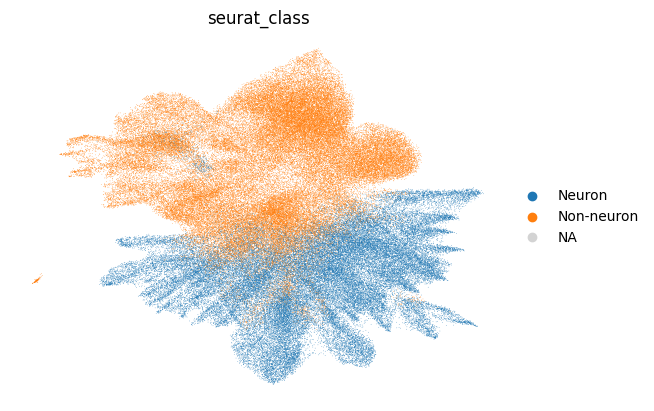

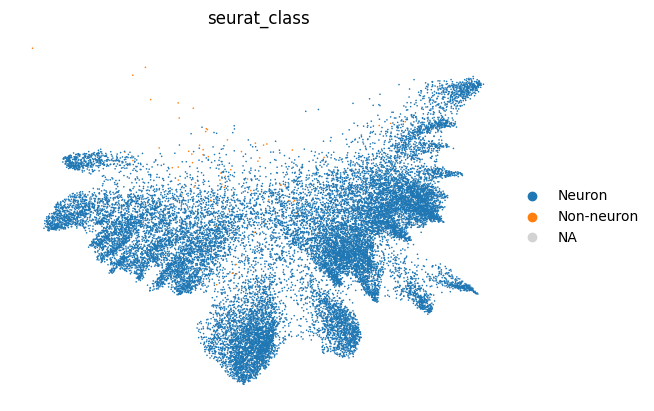

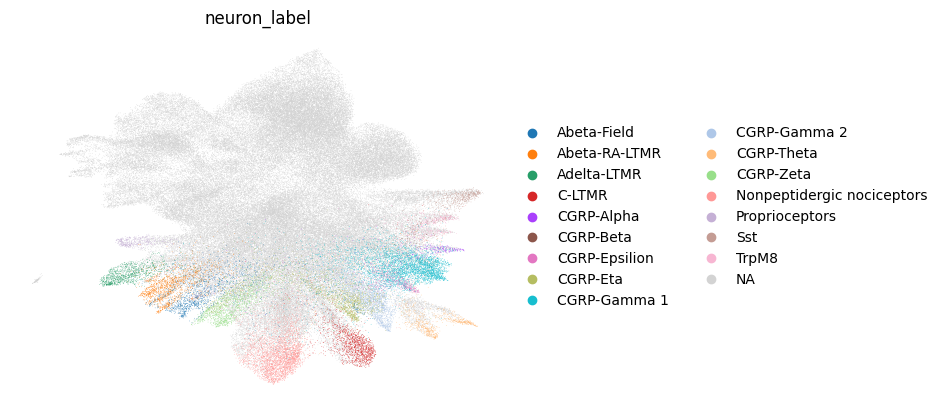

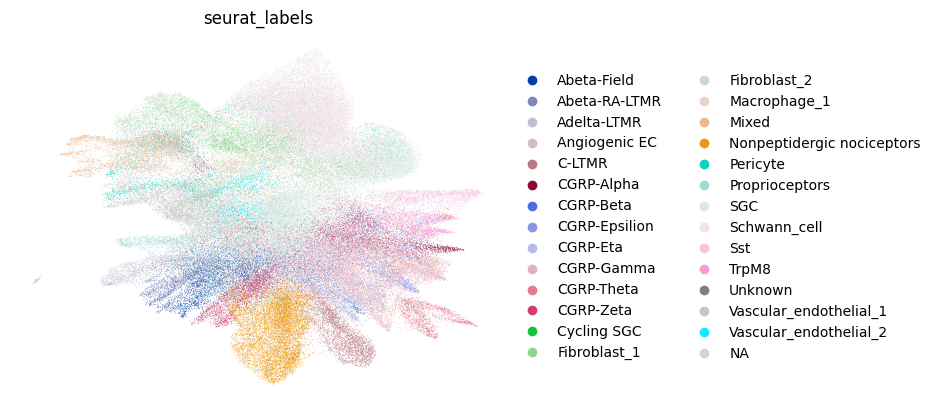

In [14]:
sc.pl.embedding(adata_global, basis = 'X_umap', color = 'seurat_class', frameon=False)
sc.pl.embedding(adata_global[adata_global.obs['total_counts']>1000, :], basis = 'X_umap', color = 'seurat_class', frameon=False)
sc.pl.embedding(adata_global, basis = 'X_umap', color = 'neuron_label', frameon=False)
sc.pl.embedding(adata_global, basis = 'X_umap', color = 'seurat_labels', frameon=False)


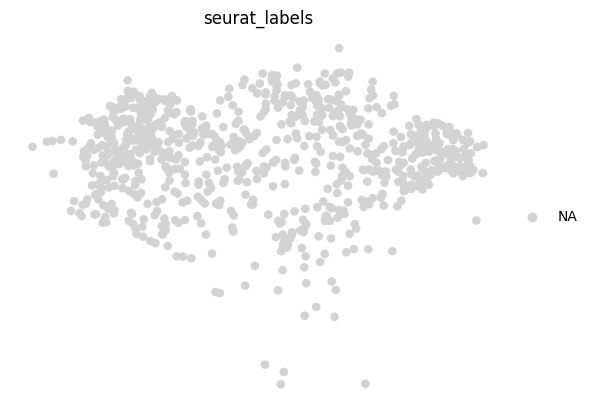

In [15]:
nan_mask = adata_global.obs['seurat_labels'].isna()
sc.pl.embedding(adata_global[nan_mask, :], basis = 'X_umap', color = 'seurat_labels', frameon=False)

### How many neurons were removed by the 1000 tran/cell filter?

In [16]:
# adata_global

In [17]:
n_neuron = sum(adata_global.obs['seurat_class']=='Neuron')
n_neuron_filt = sum( (adata_global.obs['seurat_class']=='Neuron') & (adata_global.obs['total_counts']>=1000))
print(n_neuron)
print(n_neuron_filt)
print(adata.shape)

63591
22411
(22411, 475)


## Squidy spatial analysis 

For spatial co-localization, we want to use the data object with all labeled cells. We could either use the entire global labeled dataset prior to applying the 1000 transcripts/cell filter to just the neurons, or we could start after that filtering step. Let's start with the global object prior to the 1k filtering. 

### Running on global adata

In [18]:
# run neighbor graph
sq.gr.spatial_neighbors(adata_global, 
                        library_key = 'sample_id', 
                        coord_type = 'generic', 
                        delaunay = True)

In [19]:
# remove the small number of cells with nan labels
nan_mask = adata_global.obs['seurat_labels'].isna()
print(f"number of cells with seurat_labels = nan (removing): {sum(nan_mask)}")
adata_global_prox = adata_global[~nan_mask, :]
print(adata_global_prox.shape)

number of cells with seurat_labels = nan (removing): 786
(146250, 475)


In [ ]:
# # using only adata_foll, not using fraction threshold for columns
# int_df = run_squidpy_interactions(
#     adata_global,
#     label_col = 'seurat_labels')

In [21]:
sq.gr.nhood_enrichment(adata_global_prox, cluster_key="seurat_labels")

100%|██████████| 1000/1000 [00:08<00:00, 114.11/s]
/home/workspace/environment/sc-scvi/lib/python3.12/site-packages/squidpy/gr/_utils.py:194: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  obj[key] = data


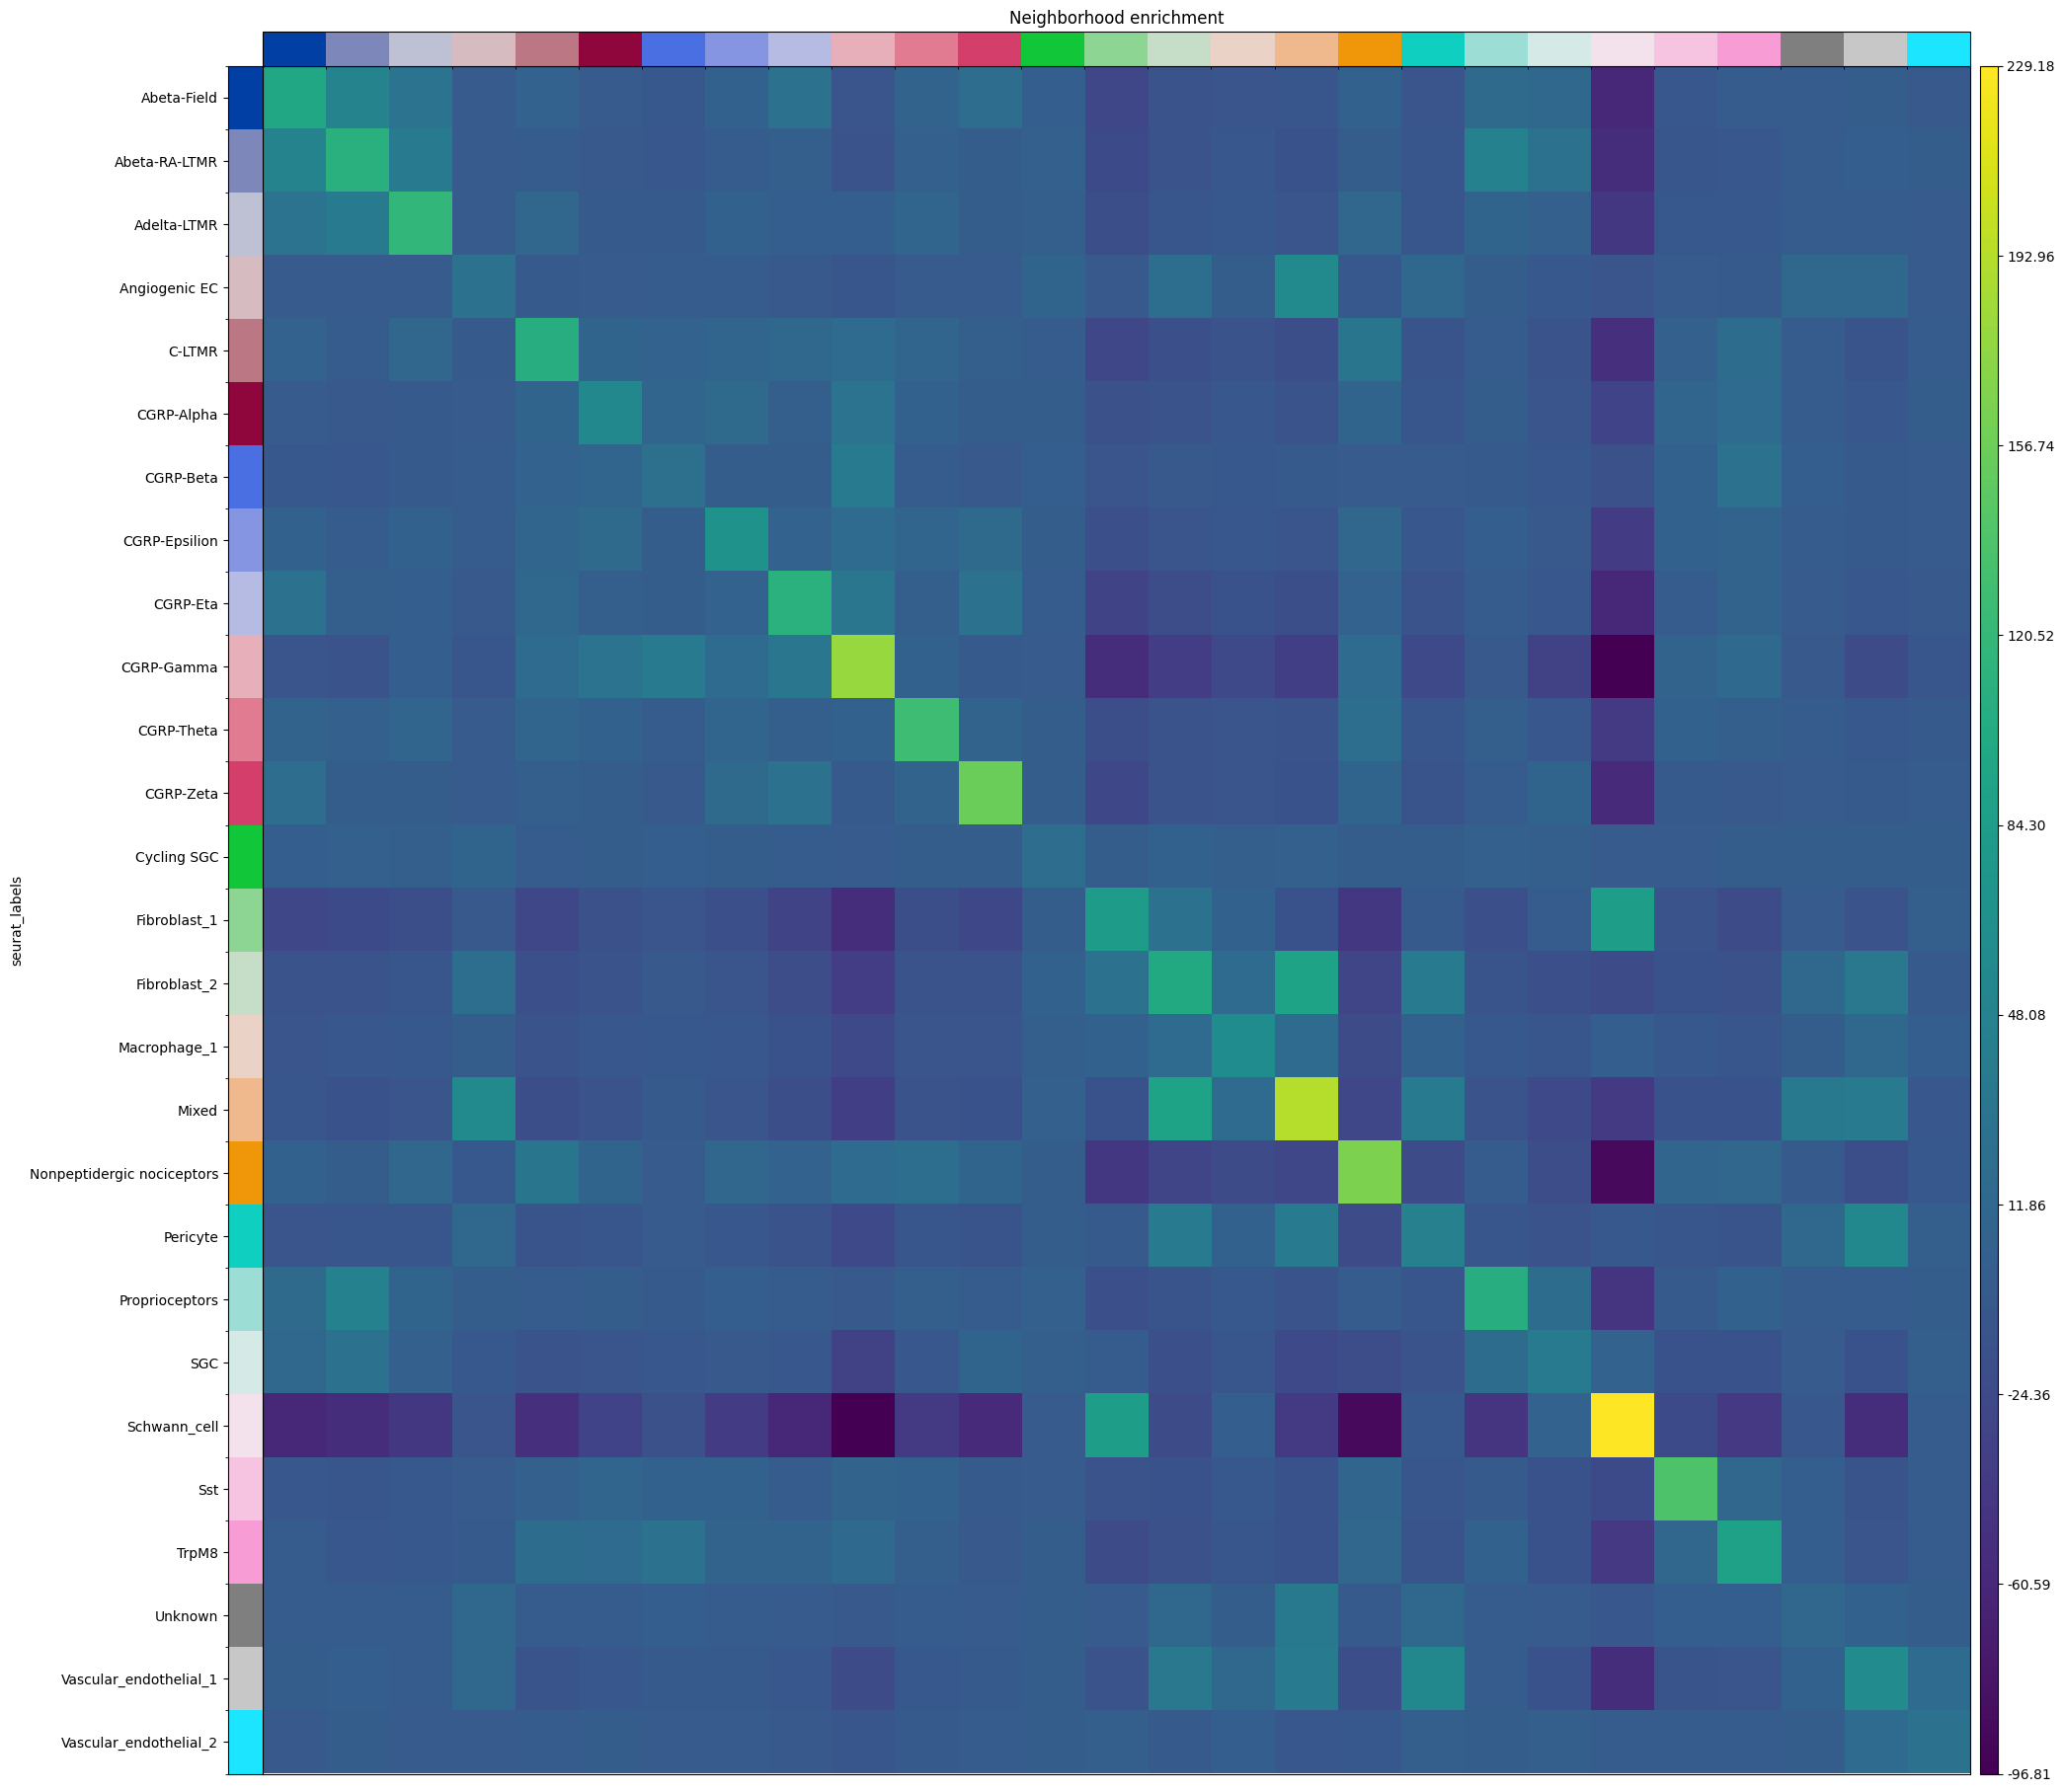

In [22]:
# fig, ax = plt.subplots(1, 2, figsize=(13, 7))
sq.pl.nhood_enrichment(
    adata_global_prox,
    cluster_key="seurat_labels",
    # figsize=(8, 8),
    # ax=ax[0],
)


### Run on neurons

In [23]:
# run neighbor graph
sq.gr.spatial_neighbors(adata, 
                        library_key = 'sample_id', 
                        coord_type = 'generic', 
                        delaunay = True)

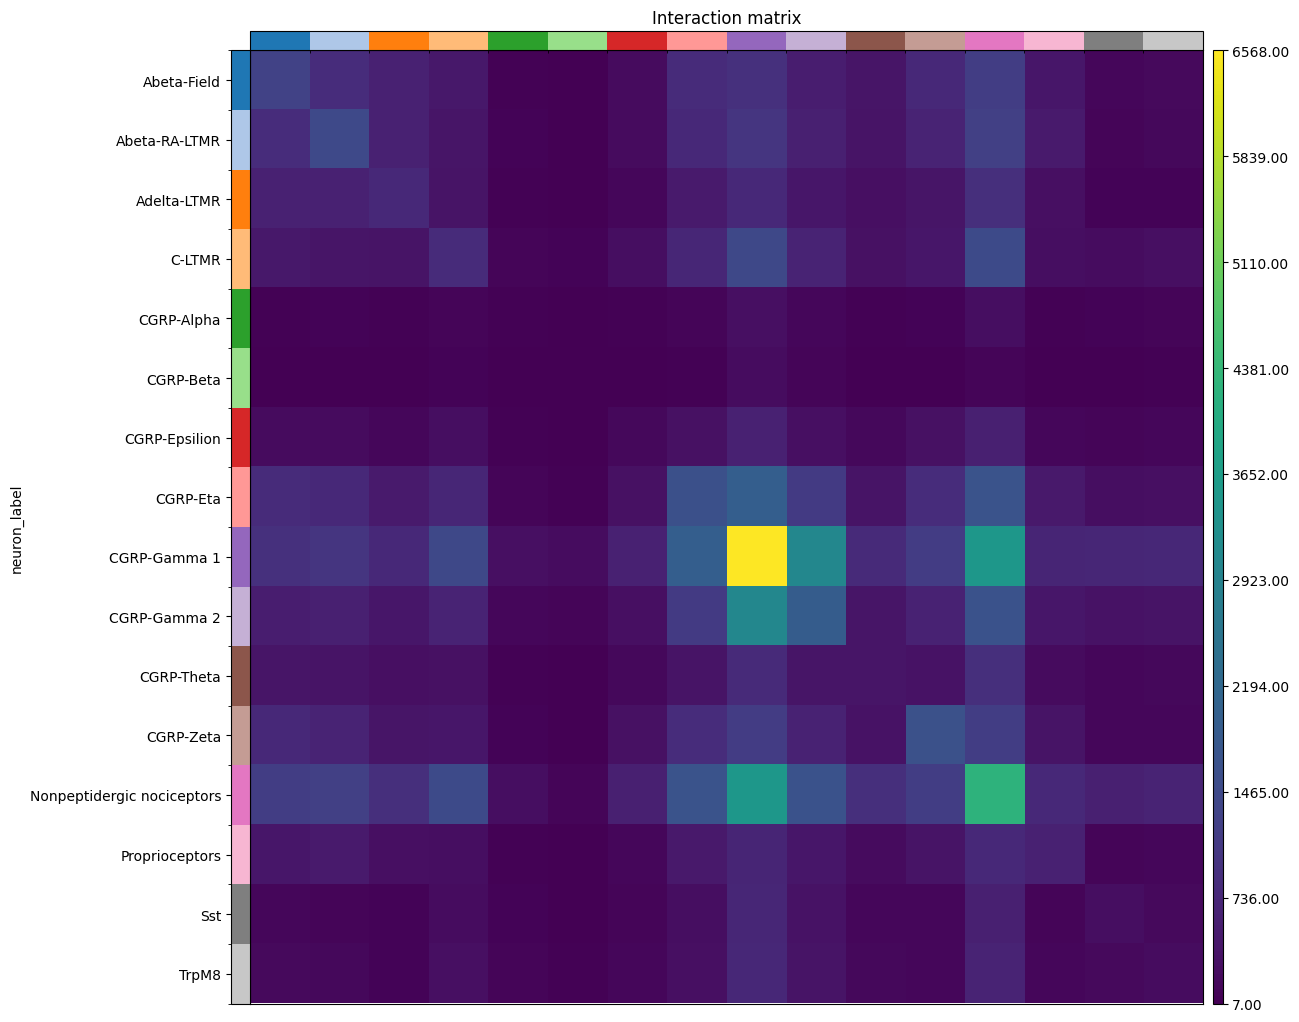

In [24]:
sq.gr.interaction_matrix(adata, cluster_key="neuron_label")
sq.pl.interaction_matrix(adata, cluster_key="neuron_label")

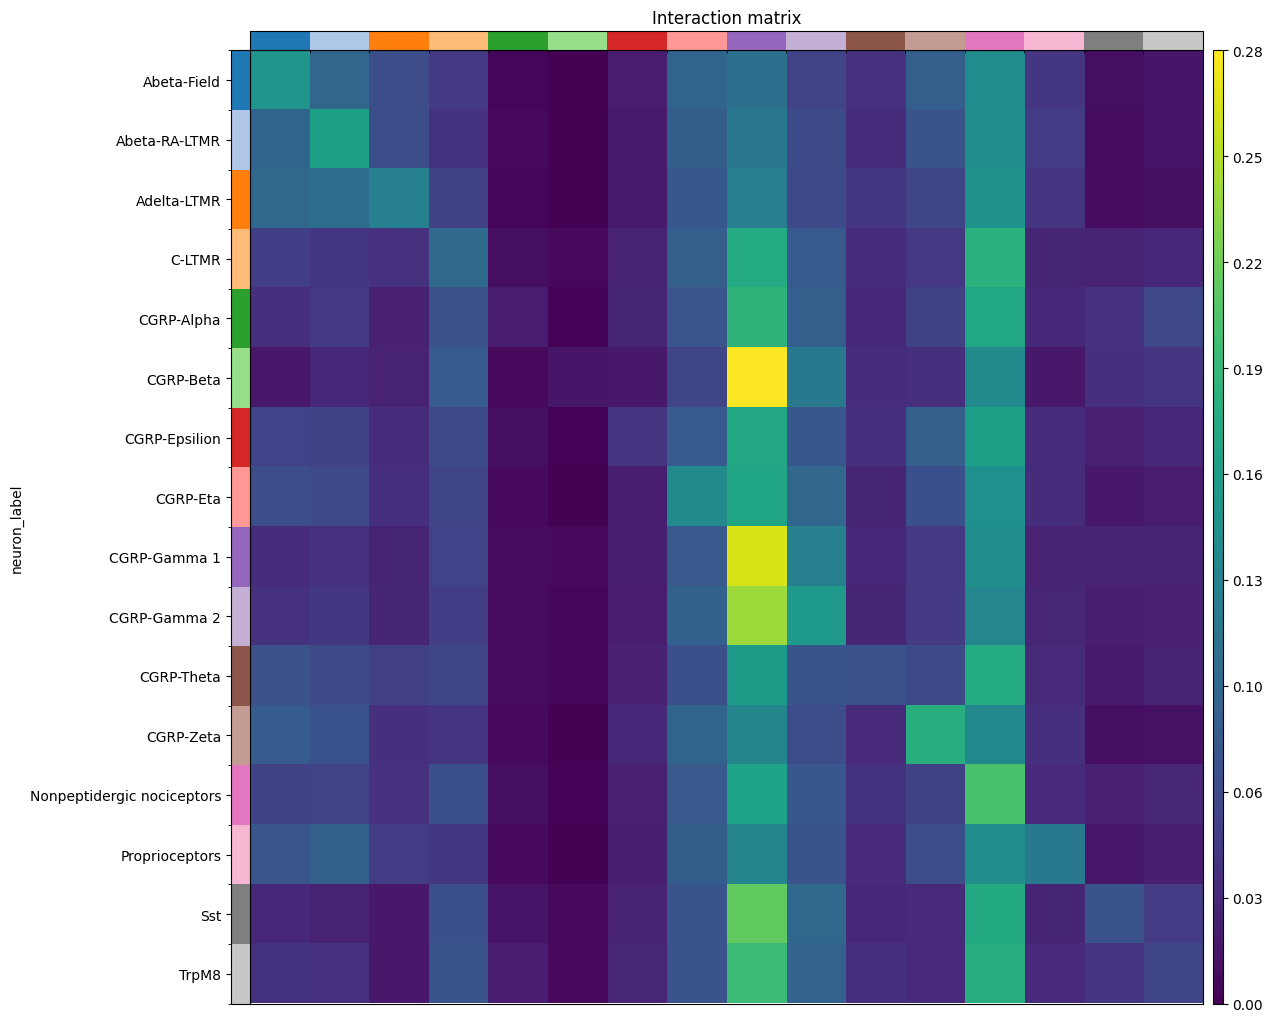

In [25]:
sq.gr.interaction_matrix(adata, cluster_key="neuron_label", normalized = True)
sq.pl.interaction_matrix(adata, cluster_key="neuron_label")

100%|██████████| 1000/1000 [00:01<00:00, 754.51/s]


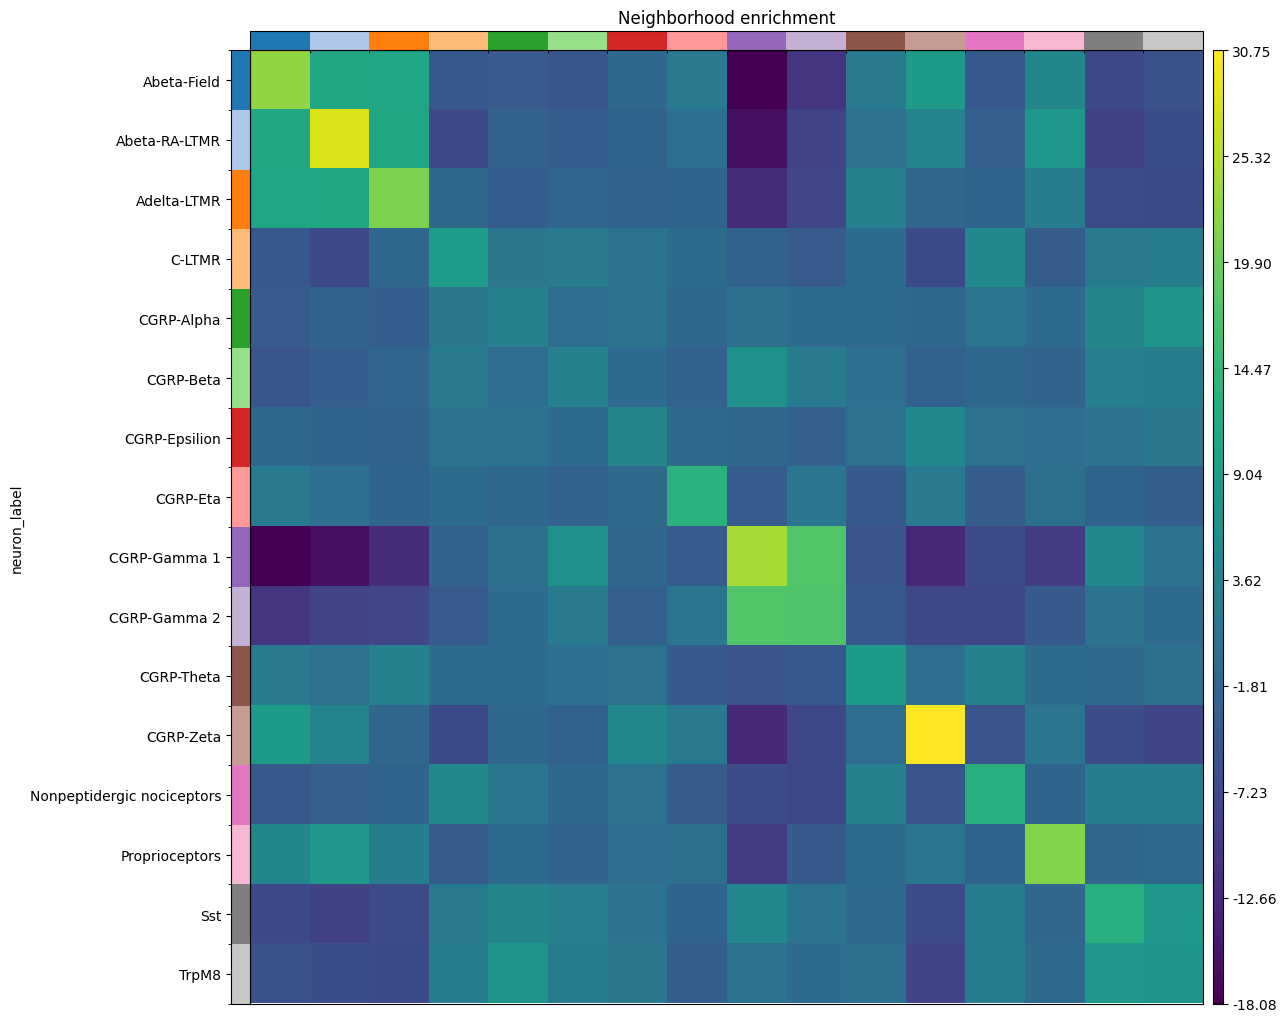

In [26]:
sq.gr.nhood_enrichment(adata, cluster_key="neuron_label")
sq.pl.nhood_enrichment(adata,cluster_key="neuron_label")

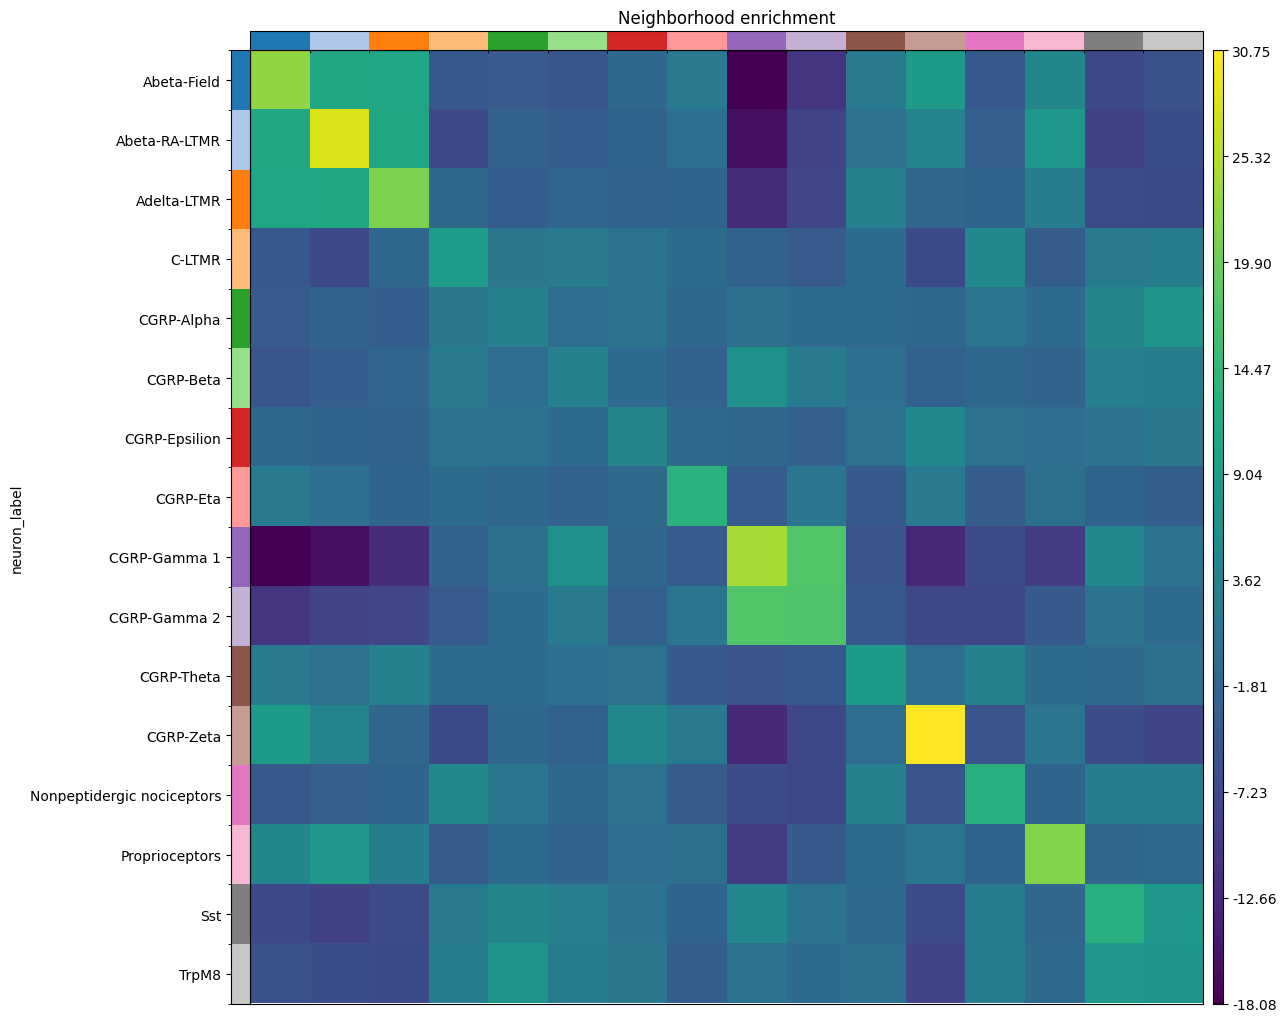

In [27]:
# fig, ax = plt.subplots(1, 2, figsize=(13, 7))
sq.pl.nhood_enrichment(
    adata,
    cluster_key="neuron_label",
    # figsize=(8, 8),
    # ax=ax[0],
)


/home/workspace/environment/sc-scvi/lib/python3.12/site-packages/anndata/_core/anndata.py:1145: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/workspace/environment/sc-scvi/lib/python3.12/site-packages/squidpy/pl/_spatial_utils.py:981: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


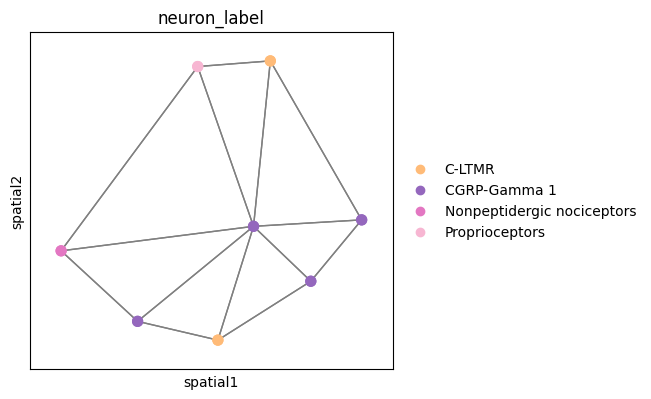

In [28]:
cats = adata.obs["neuron_label"].cat.categories

row = np.where(adata.obs['neuron_label'] == 'CGRP-Gamma 1')[0][0]
for key_added in ['spatial']:
    _, idx = adata.obsp[f"{key_added}_connectivities"][row, :].copy().nonzero()
    idx = np.append(idx, row)
    sq.pl.spatial_scatter(
        adata[idx, :],
        # spatial_key = 'X_spatial',
        shape=None,
        color="neuron_label",
        connectivity_key='spatial_connectivities',
        size=200,
        library_key = 'sample_id',
    )

### Run on neurons - try radius based spatial graph

In [29]:
# run neighbor graph
sq.gr.spatial_neighbors(adata, 
                        library_key = 'sample_id', 
                        coord_type = 'generic', 
                        radius = 25,
                        key_added = 'spatial_25um',
                        delaunay = False)

In [30]:
# run neighbor graph
sq.gr.spatial_neighbors(adata, 
                        library_key = 'sample_id', 
                        coord_type = 'generic', 
                        radius = 50,
                        key_added = 'spatial_50um',
                        delaunay = False)

In [31]:
# run neighbor graph
sq.gr.spatial_neighbors(adata, 
                        library_key = 'sample_id', 
                        coord_type = 'generic', 
                        radius = 100,
                        key_added = 'spatial_100um',
                        delaunay = False)

/home/workspace/environment/sc-scvi/lib/python3.12/site-packages/anndata/_core/anndata.py:1145: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/workspace/environment/sc-scvi/lib/python3.12/site-packages/squidpy/pl/_spatial_utils.py:981: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
/home/workspace/environment/sc-scvi/lib/python3.12/site-packages/anndata/_core/anndata.py:1145: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/workspace/environment/sc-scvi/lib/python3.12/site-packages/squidpy/pl/_spatial_utils.py:981: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
/home/workspace/environment/sc-scvi/lib/python3.12/site-packages/anndata/_core/anndata.py:1145: ImplicitModificationWarning: Trying to modify attrib

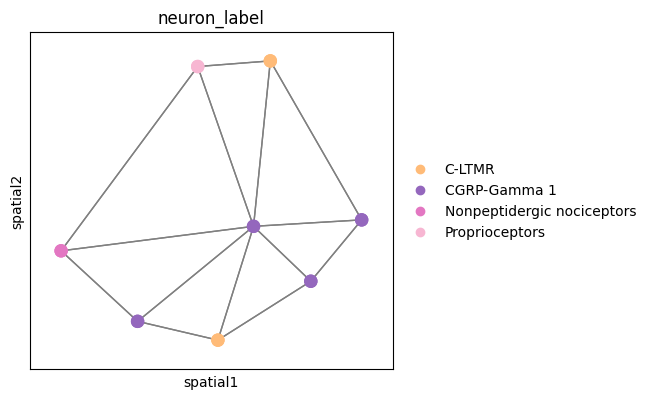

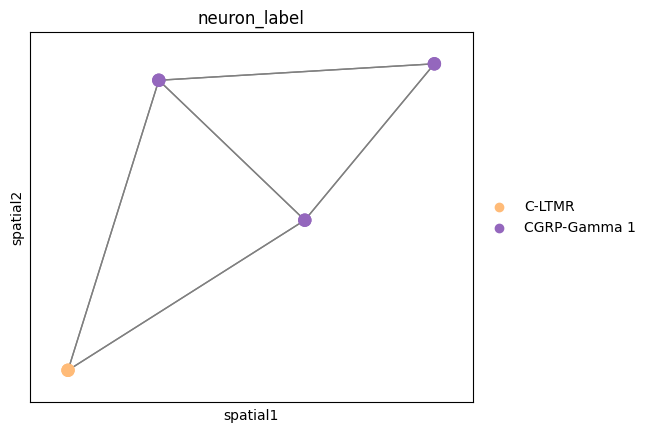

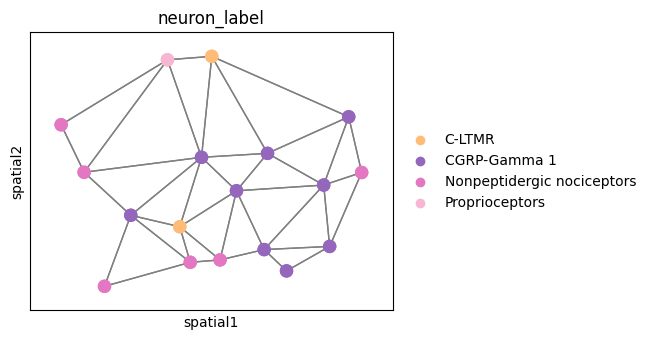

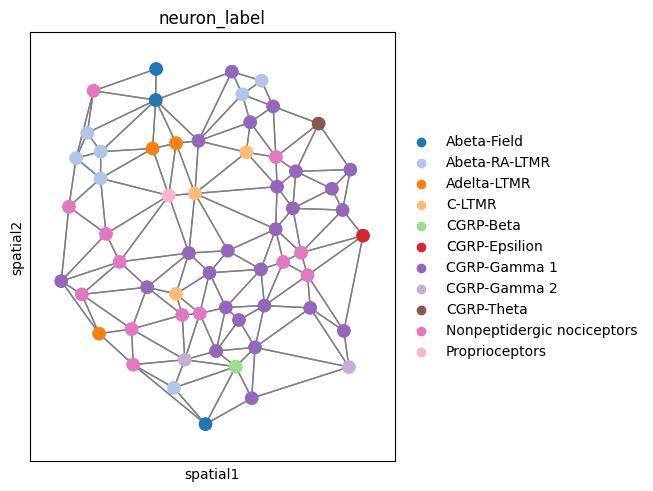

In [32]:
cats = adata.obs["neuron_label"].cat.categories

row = np.where(adata.obs['neuron_label'] == 'CGRP-Gamma 1')[0][0]
for key_added in ['spatial', 'spatial_25um', 'spatial_50um', 'spatial_100um']:
    _, idx = adata.obsp[f"{key_added}_connectivities"][row, :].copy().nonzero()
    idx = np.append(idx, row)
    sq.pl.spatial_scatter(
        adata[idx, :],
        # spatial_key = 'X_spatial',
        shape=None,
        color="neuron_label",
        connectivity_key='spatial_connectivities',
        size=300,
        library_key = 'sample_id',
    )

/home/workspace/environment/sc-scvi/lib/python3.12/site-packages/anndata/_core/anndata.py:1145: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/workspace/environment/sc-scvi/lib/python3.12/site-packages/squidpy/pl/_spatial_utils.py:981: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
/home/workspace/environment/sc-scvi/lib/python3.12/site-packages/anndata/_core/anndata.py:1145: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/workspace/environment/sc-scvi/lib/python3.12/site-packages/squidpy/pl/_spatial_utils.py:981: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
/home/workspace/environment/sc-scvi/lib/python3.12/site-packages/anndata/_core/anndata.py:1145: ImplicitModificationWarning: Trying to modify attrib

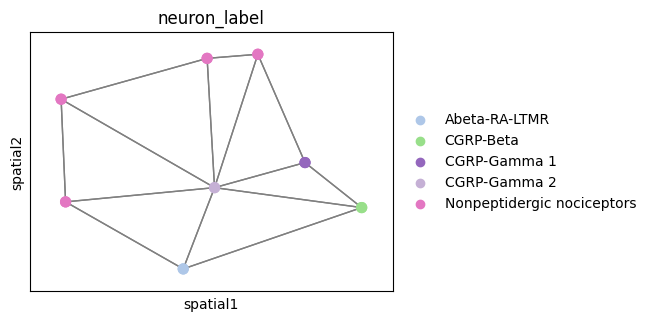

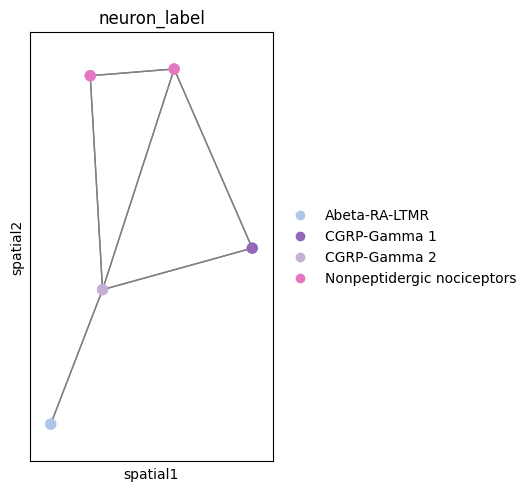

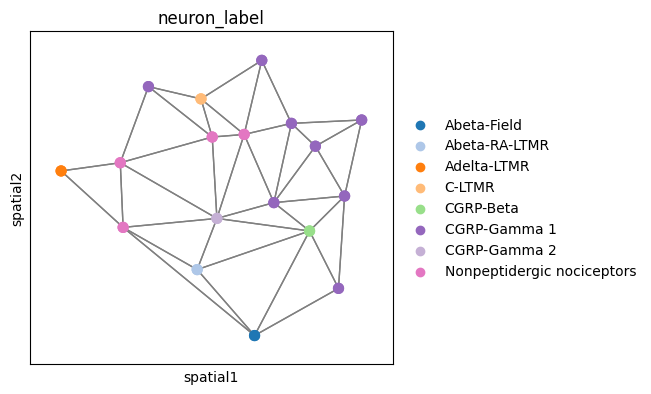

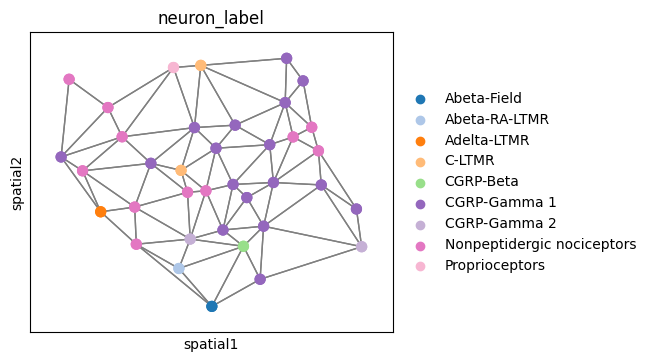

In [33]:
cats = adata.obs["neuron_label"].cat.categories

row = np.where(adata.obs['neuron_label'] == 'CGRP-Gamma 2')[0][0]
for key_added in ['spatial', 'spatial_25um', 'spatial_50um', 'spatial_100um']:
    _, idx = adata.obsp[f"{key_added}_connectivities"][row, :].copy().nonzero()
    idx = np.append(idx, row)
    sq.pl.spatial_scatter(
        adata[idx, :],
        # spatial_key = 'X_spatial',
        shape=None,
        color="neuron_label",
        connectivity_key='spatial_connectivities',
        size=200,
        library_key = 'sample_id',
    )

/home/workspace/environment/sc-scvi/lib/python3.12/site-packages/anndata/_core/anndata.py:1145: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/workspace/environment/sc-scvi/lib/python3.12/site-packages/squidpy/pl/_spatial_utils.py:981: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
/home/workspace/environment/sc-scvi/lib/python3.12/site-packages/anndata/_core/anndata.py:1145: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/workspace/environment/sc-scvi/lib/python3.12/site-packages/squidpy/pl/_spatial_utils.py:981: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
/home/workspace/environment/sc-scvi/lib/python3.12/site-packages/anndata/_core/anndata.py:1145: ImplicitModificationWarning: Trying to modify attrib

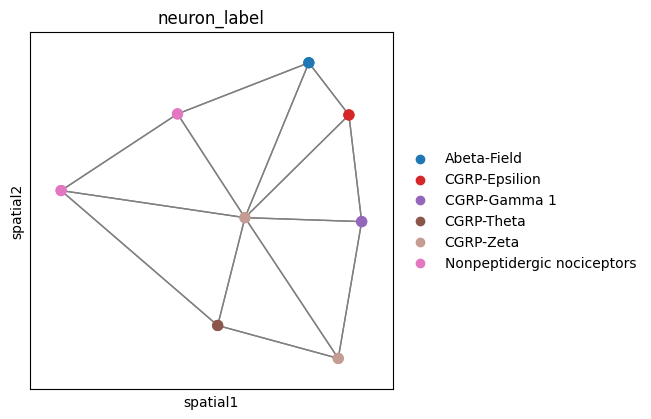

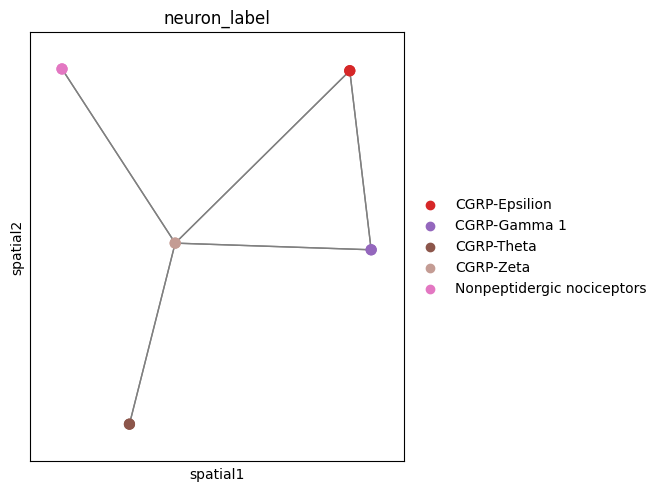

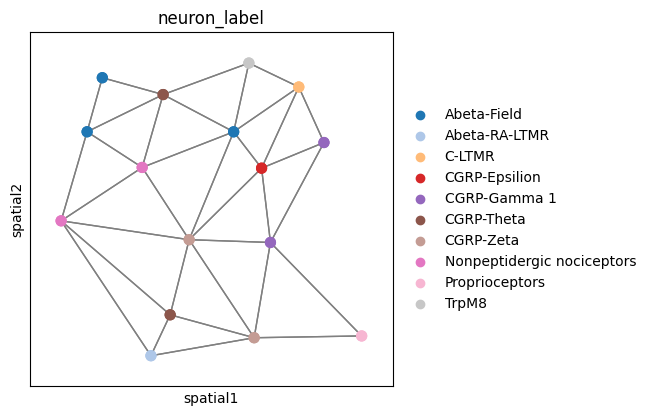

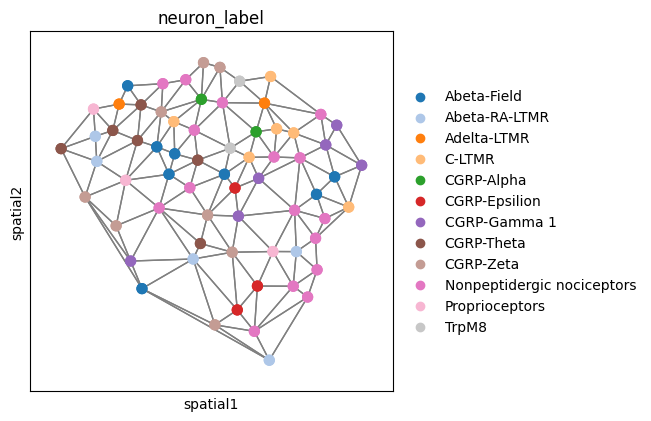

In [38]:
cats = adata.obs["neuron_label"].cat.categories

row = np.where(adata.obs['neuron_label'] == 'CGRP-Zeta')[0][2]
for key_added in ['spatial', 'spatial_25um', 'spatial_50um', 'spatial_100um']:
    _, idx = adata.obsp[f"{key_added}_connectivities"][row, :].copy().nonzero()
    idx = np.append(idx, row)
    sq.pl.spatial_scatter(
        adata[idx, :],
        # spatial_key = 'X_spatial',
        shape=None,
        color="neuron_label",
        connectivity_key='spatial_connectivities',
        size=200,
        library_key = 'sample_id',
    )

100%|██████████| 1000/1000 [00:02<00:00, 450.52/s]


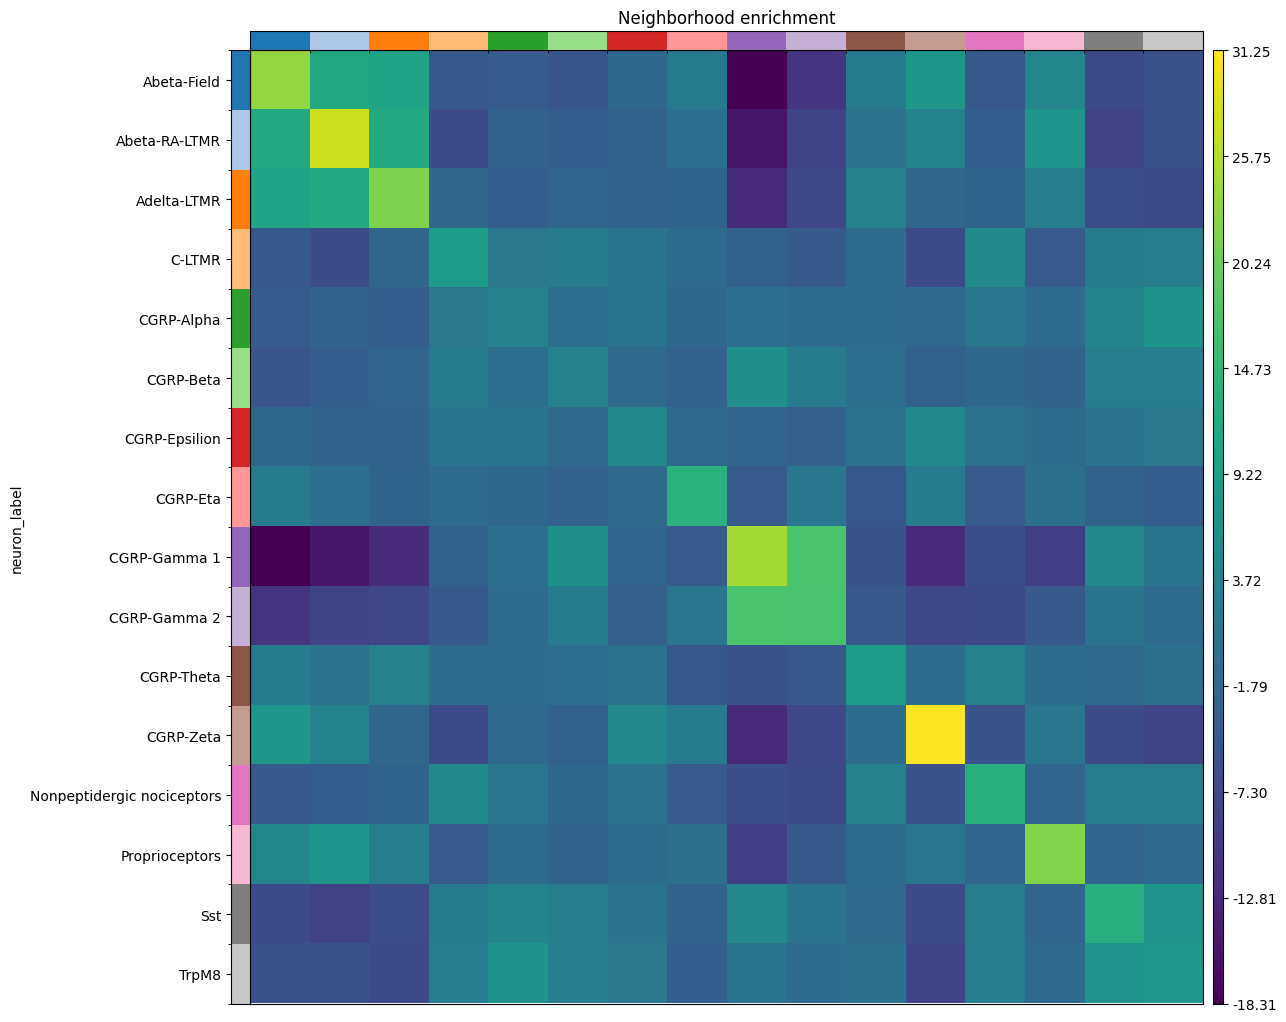

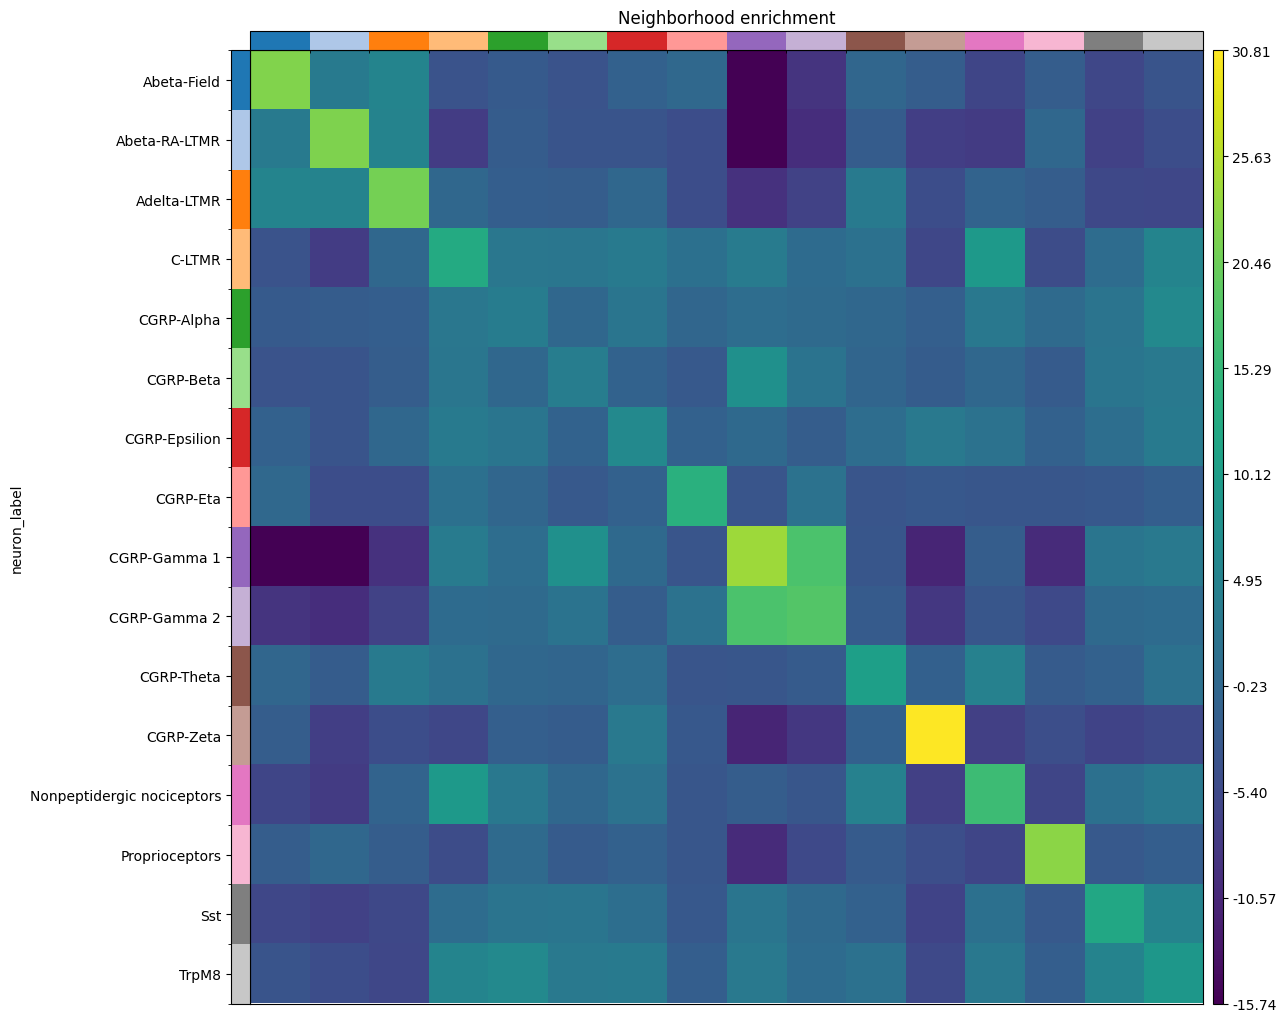

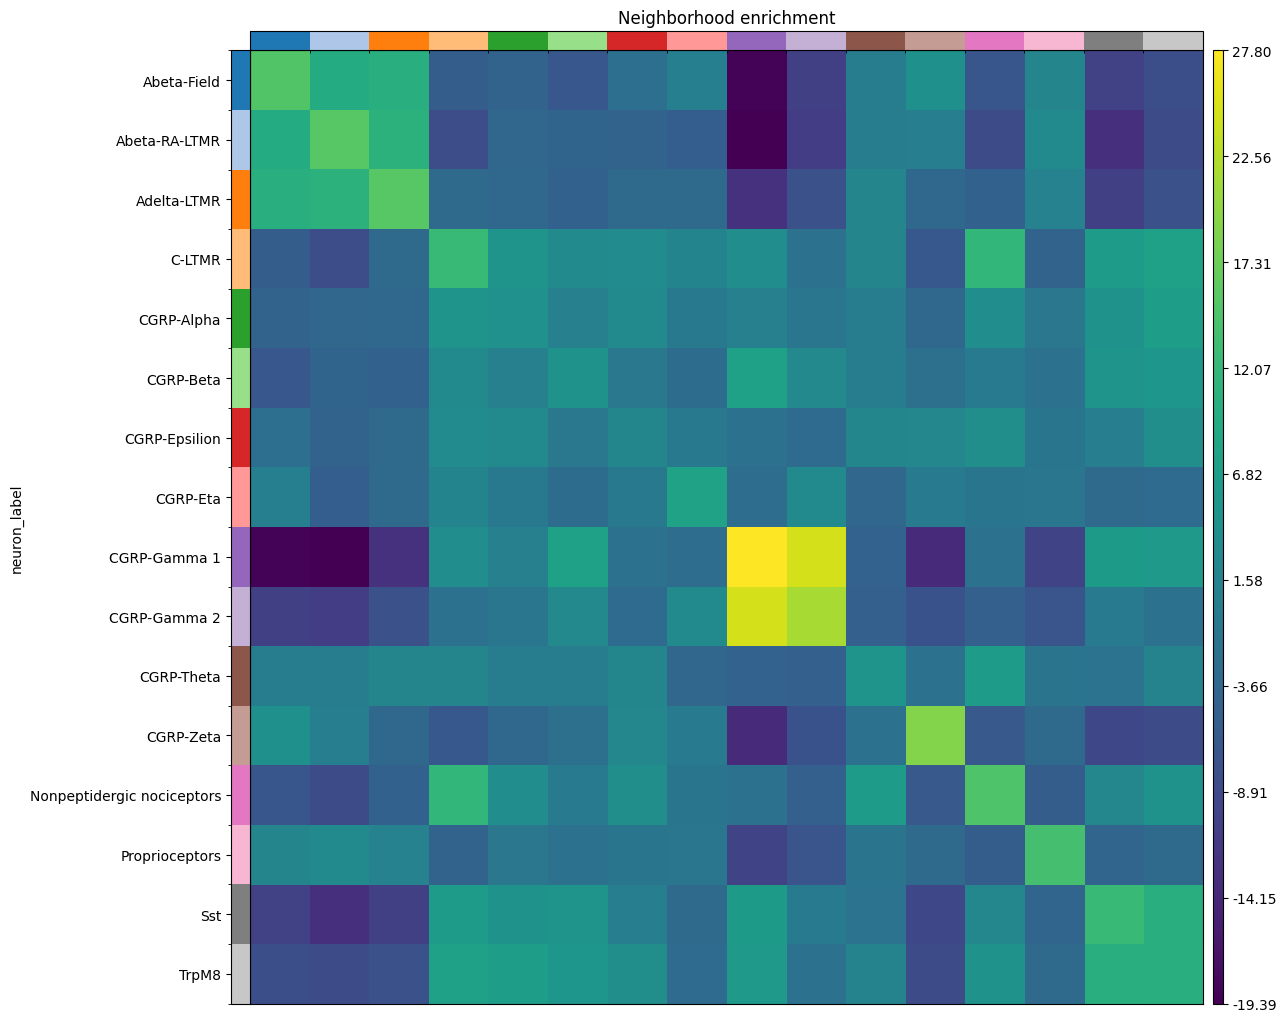

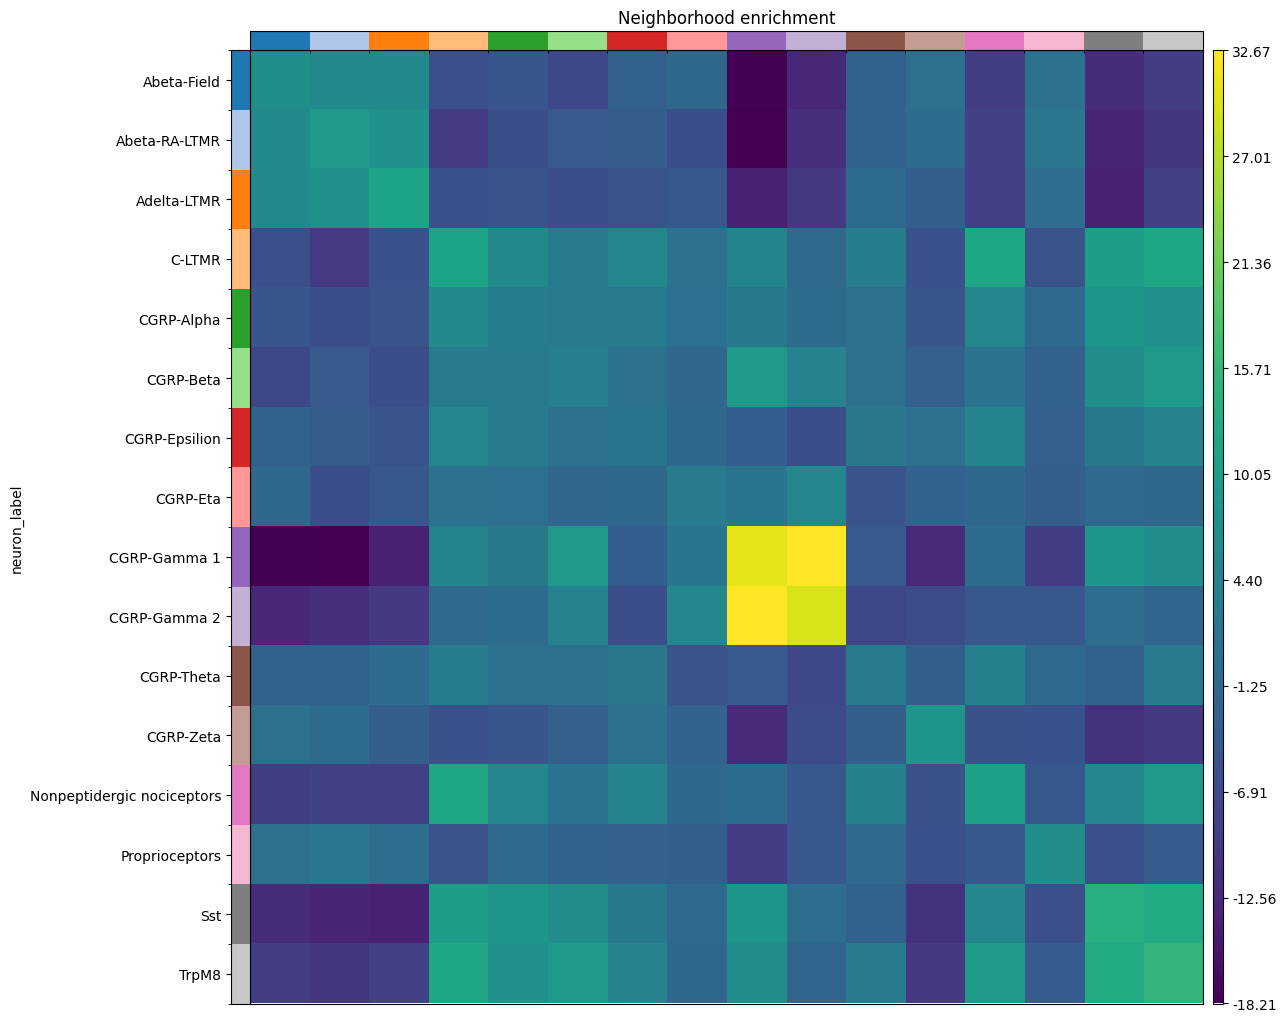

In [35]:
sq.gr.nhood_enrichment(adata, cluster_key="neuron_label" )
sq.pl.nhood_enrichment(adata,cluster_key="neuron_label")

sq.gr.nhood_enrichment(adata, cluster_key="neuron_label", connectivity_key = 'spatial_25um')
sq.pl.nhood_enrichment(adata,cluster_key="neuron_label", connectivity_key = 'spatial_25um')

sq.gr.nhood_enrichment(adata, cluster_key="neuron_label", connectivity_key = 'spatial_50um')
sq.pl.nhood_enrichment(adata,cluster_key="neuron_label", connectivity_key = 'spatial_50um')

sq.gr.nhood_enrichment(adata, cluster_key="neuron_label", connectivity_key = 'spatial_100um')
sq.pl.nhood_enrichment(adata,cluster_key="neuron_label", connectivity_key = 'spatial_100um')

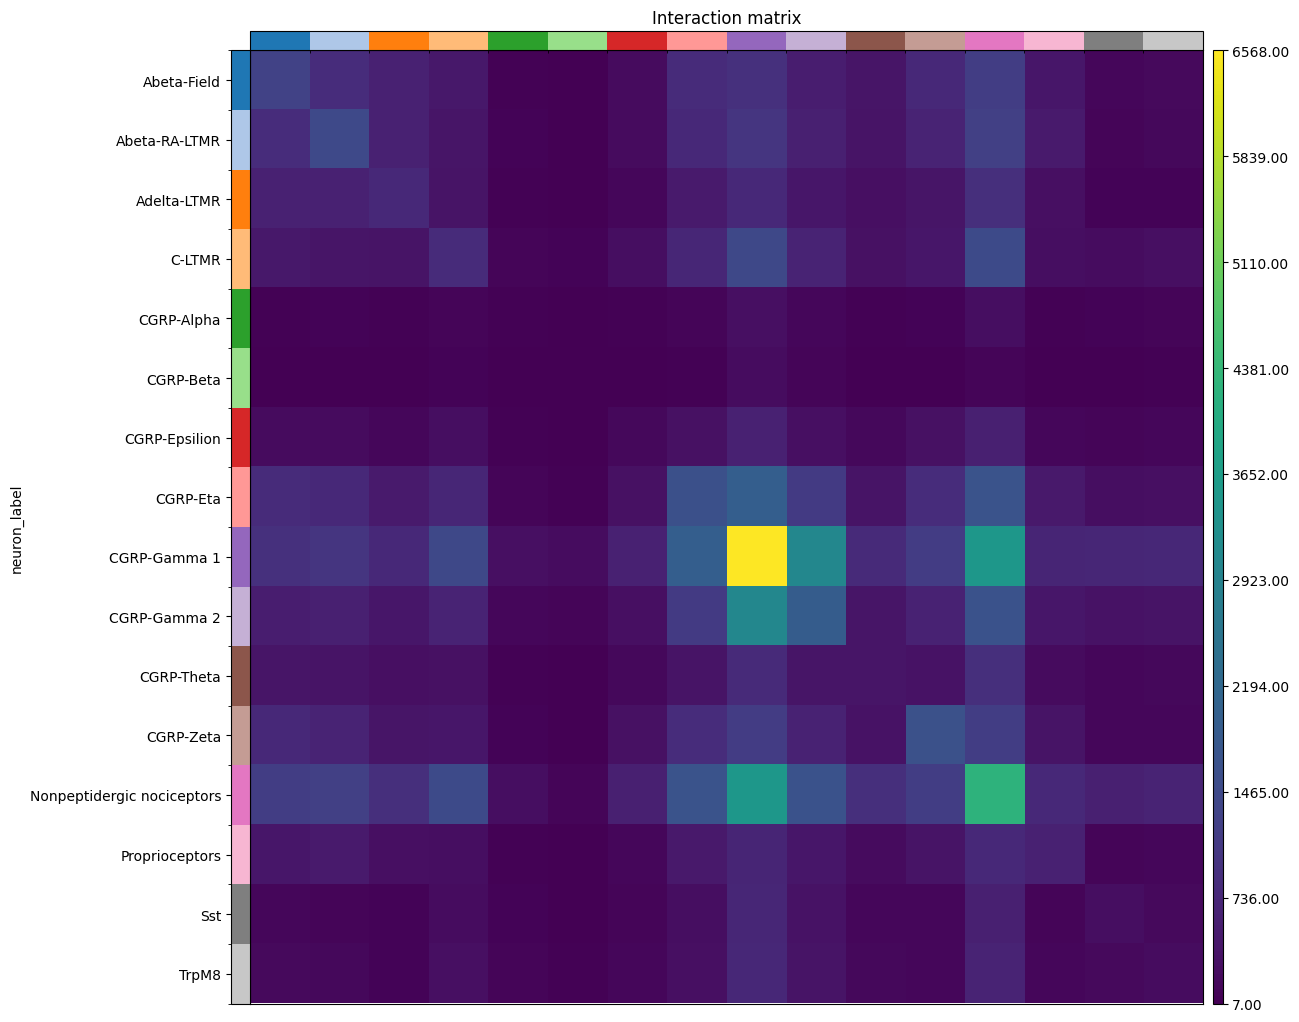

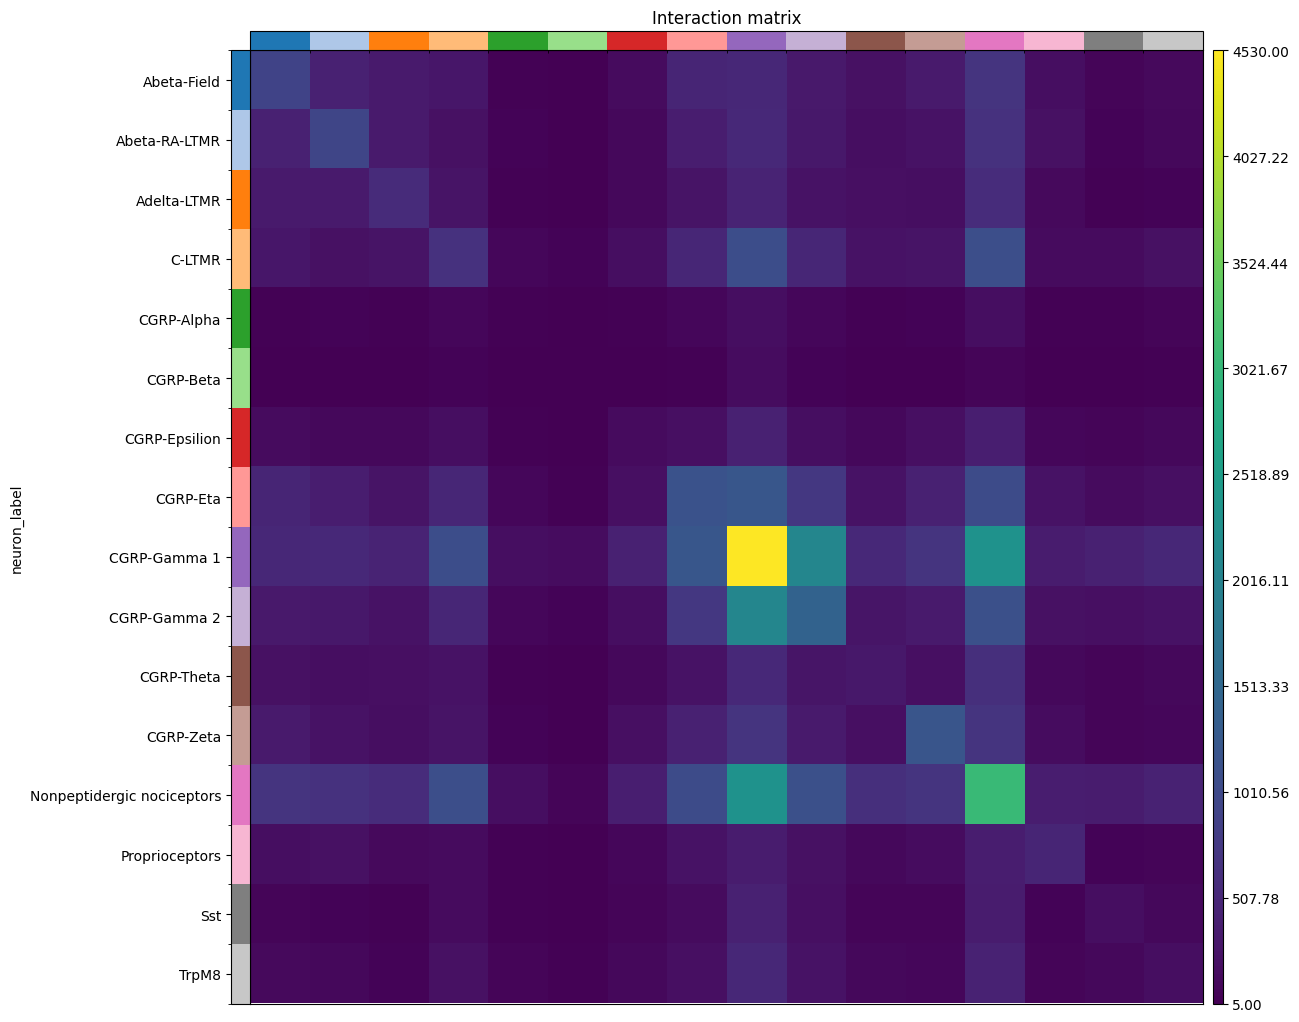

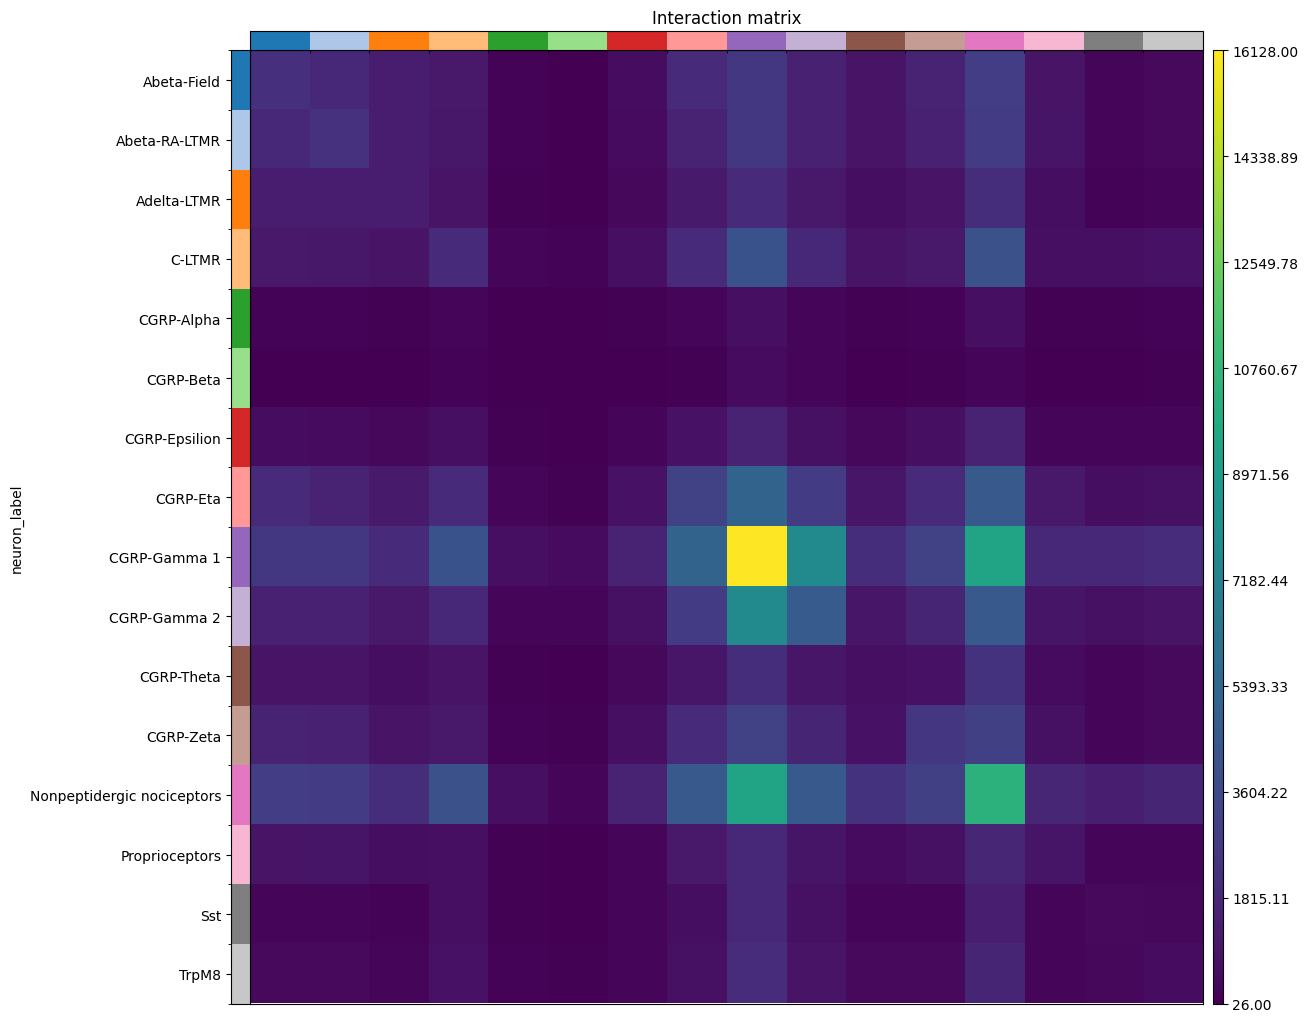

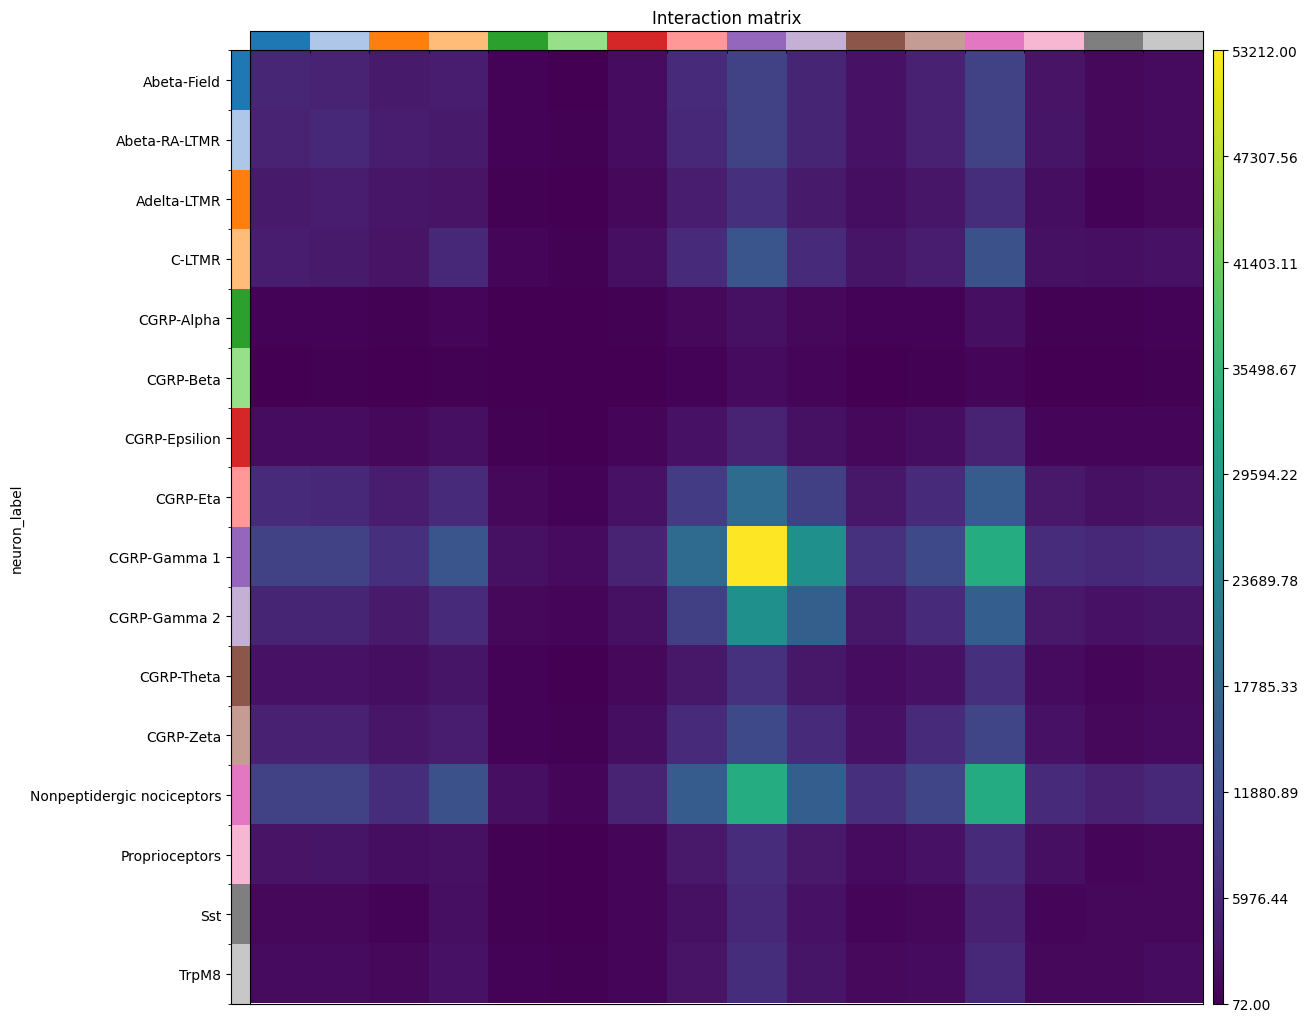

In [36]:
# interaction matrix
sq.gr.interaction_matrix(adata, cluster_key="neuron_label")
sq.pl.interaction_matrix(adata, cluster_key="neuron_label")

sq.gr.interaction_matrix(adata, cluster_key="neuron_label", connectivity_key = 'spatial_25um')
sq.pl.interaction_matrix(adata, cluster_key="neuron_label", connectivity_key = 'spatial_25um')

sq.gr.interaction_matrix(adata, cluster_key="neuron_label", connectivity_key = 'spatial_50um')
sq.pl.interaction_matrix(adata, cluster_key="neuron_label", connectivity_key = 'spatial_50um')

sq.gr.interaction_matrix(adata, cluster_key="neuron_label", connectivity_key = 'spatial_100um')
sq.pl.interaction_matrix(adata, cluster_key="neuron_label", connectivity_key = 'spatial_100um')

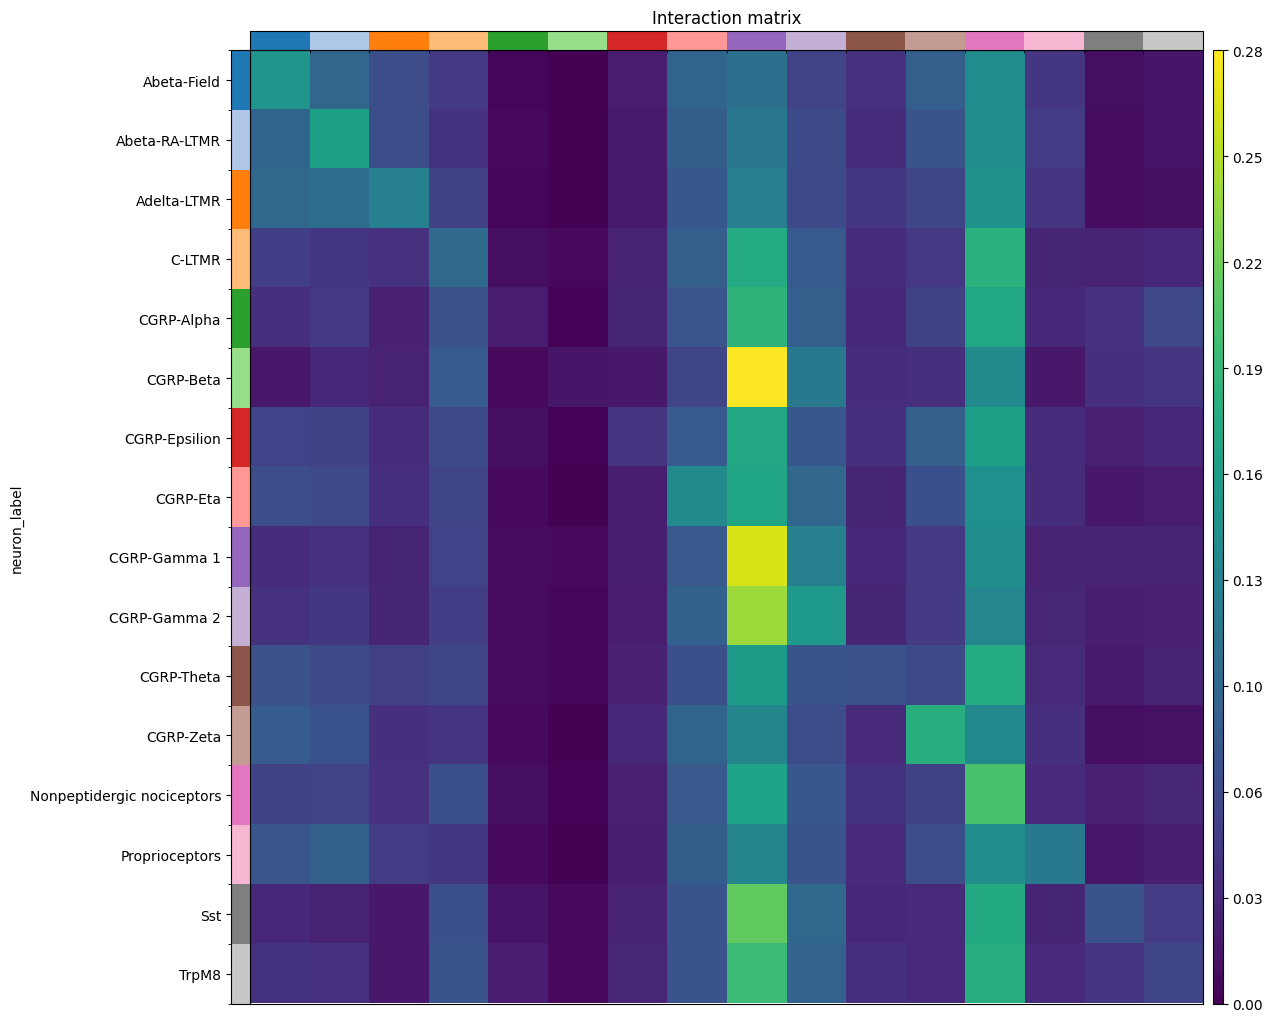

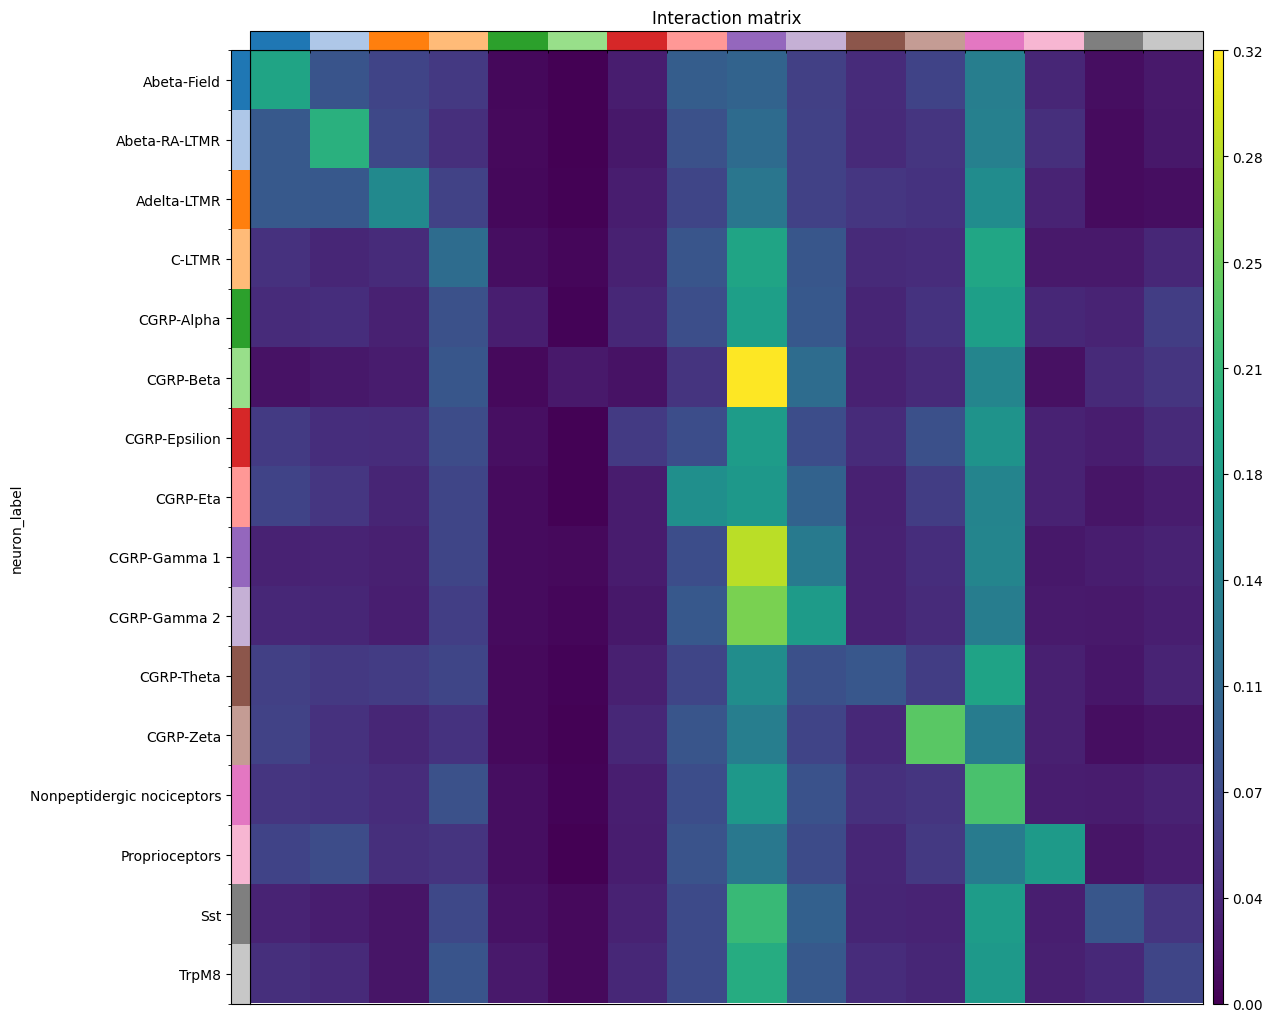

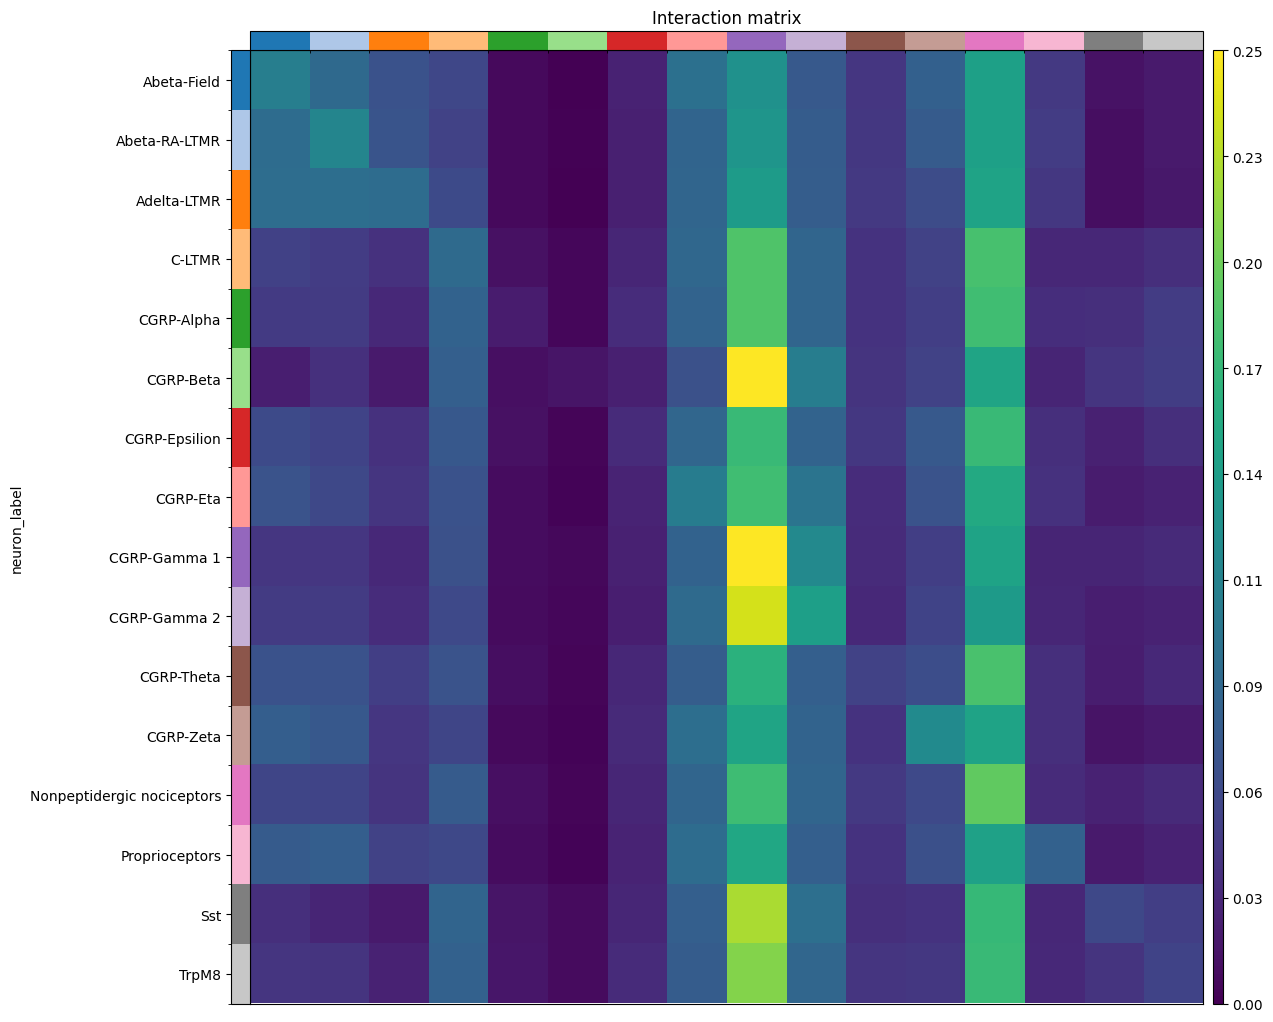

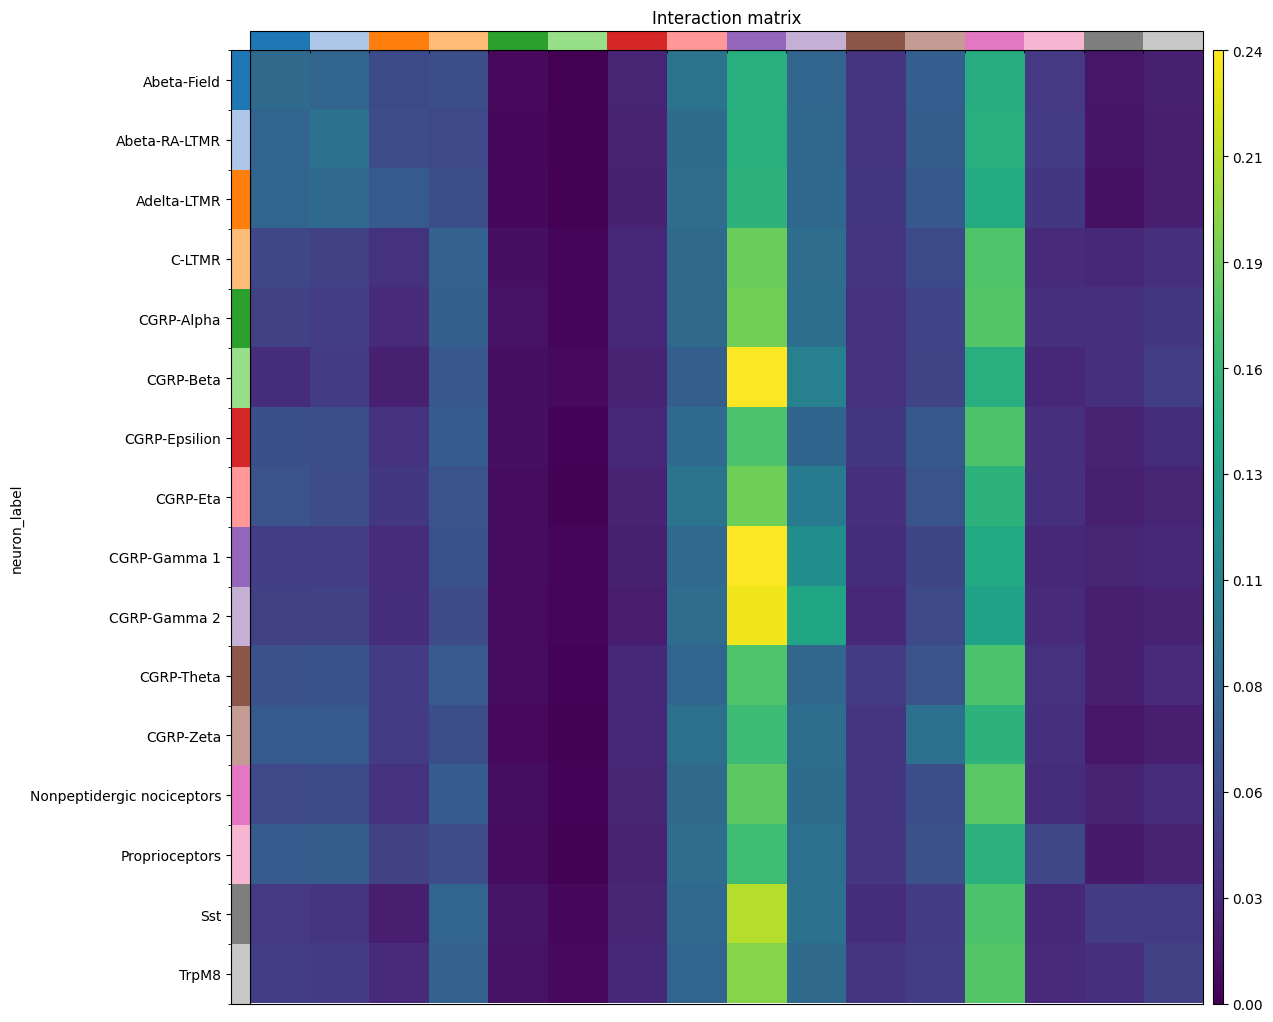

In [37]:
# interaction matrix
sq.gr.interaction_matrix(adata, cluster_key="neuron_label", normalized = True)
sq.pl.interaction_matrix(adata, cluster_key="neuron_label")

sq.gr.interaction_matrix(adata, cluster_key="neuron_label", normalized = True,  connectivity_key = 'spatial_25um')
sq.pl.interaction_matrix(adata, cluster_key="neuron_label", connectivity_key = 'spatial_25um')

sq.gr.interaction_matrix(adata, cluster_key="neuron_label", normalized = True,  connectivity_key = 'spatial_50um')
sq.pl.interaction_matrix(adata, cluster_key="neuron_label", connectivity_key = 'spatial_50um')

sq.gr.interaction_matrix(adata, cluster_key="neuron_label", normalized = True,  connectivity_key = 'spatial_100um')
sq.pl.interaction_matrix(adata, cluster_key="neuron_label", connectivity_key = 'spatial_100um')